<a href="https://colab.research.google.com/github/manubastidas/programacionCientifica/blob/eval2-MarulandaDur%C3%A1n/Evaluacion2/MarulandaDur%C3%A1n/solucion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
##Inicialización de LaTeX

# [Ajuste ejecución local] Comandos de Colab (apt-get/pip) omitidos: LaTeX y jax ya están instalados en el entorno local.
# !sudo apt-get update
# !sudo apt-get install texlive-latex-extra texlive-fonts-recommended dvipng cm-super
# !pip install -q jax jaxlib optax

import numpy as np

from scipy.special import comb
from scipy.interpolate import CubicSpline, make_interp_spline

import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import matplotlib.colors as mcolors
from mpl_toolkits.mplot3d import Axes3D

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 14,

    # Ejes y Ticks
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "xtick.direction": "in",
    "ytick.direction": "in",

    # Grid
    "grid.color"    : "gray",
    "grid.linewidth": 0.3,
    "grid.alpha"    : 0.3,
    "grid.linestyle": "--",

    # Estética
    "figure.dpi"        : 120,
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "savefig.bbox"      : "tight",
    "savefig.dpi"       : 300,
})

print('Configuración OK')

Configuración OK


In [2]:
import numpy as np
import jax.numpy as jnp
import jax
from jax import random
import matplotlib.pyplot as plt

# Carga de datos
datos = np.load('../SolucionReferencia_0000/datos_0000.npz')
X = datos['X'] # Forma: (24, 256)
y = datos['y'] # Forma: (24,) con etiquetas de régimen 0, 1, 2
t = datos['t'] # Forma: (256,)

# Extraemos una señal por régimen para visualizaciones futuras
X_reg0 = X[y == 0]
X_reg1 = X[y == 1]
X_reg2 = X[y == 2]

# **1. Capa de Fourirer**

In [3]:
def construir_capa_fourier(t, K=25):
    """Construye la matriz W1 con filas de senos y cosenos."""
    # La matriz debe transformar de 256 a 50 (2K)
    W1 = np.zeros((2 * K, len(t)))

    # Asumimos que t va de 0 a un periodo T. Si t está normalizado entre 0 y 1:
    T = t[-1] - t[0] + (t[1] - t[0])

    for k in range(1, K + 1):
        # Frecuencias k
        W1[2*(k-1), :] = np.cos(2 * np.pi * k * t / T)
        W1[2*(k-1)+1, :] = np.sin(2 * np.pi * k * t / T)

    return jnp.array(W1)

W1_fourier = construir_capa_fourier(t, K=25)

# Evidencia de comparación con np.fft
x_prueba = X[0]
w1_out = W1_fourier @ x_prueba
fft_out = np.fft.fft(x_prueba)

# Reporte de la energía media del dataset
energia_media = (X**2).mean()
print(f"Energía media del dataset: {energia_media:.3f}")

Energía media del dataset: 0.678


**¿Cuáles son las entradas y salidas de np.fft?:** Las entradas de np.fft son señales temporales, y las salidas son coeficientes complejos en el dominio de la frecuencia.

**¿Se hace a una señal o a varias?:** En este caso se hace con una sola señal para verificar la inicialización de $W_1$.

**¿Para que pedimos reportar la energía media del dataset?:** Reportamos la energía media establecer un umbral base que usaremos en la sección de compresión, en dicha sección profundizaremos en esto,

# 2. Entrenamiento y reconstrucción

In [4]:
# Arquitectura de la red neuronal
def predecir(params, X_batch):
    W1, W2 = params
    # X_batch tiene forma (N, 256), la red procesa por filas
    return jnp.dot(jnp.tanh(jnp.dot(X_batch, W1.T)), W2.T)

# Función de pérdida (Error Cuadrático Medio)
def loss_fn(params, X_batch):
    X_hat = predecir(params, X_batch)
    return jnp.mean((X_hat - X_batch)**2)

# Función de actualización con descenso de gradiente
@jax.jit
def update(params, X_batch, lr=0.05):
    loss, grads = jax.value_and_grad(loss_fn)(params, X_batch)
    new_params = [p - lr * g for p, g in zip(params, grads)]
    return new_params, loss

# Inicialización de parámetros
key = random.PRNGKey(42)
key_w1, key_w2_f, key_w2_r = random.split(key, 3)

# Inicialización 1: Aleatoria
W1_random = random.normal(key_w1, (50, 256)) * 0.1
W2_random = random.normal(key_w2_r, (256, 50)) * 0.1
params_random = [W1_random, W2_random]

# Inicialización 2: Fourier
W2_fourier = random.normal(key_w2_f, (256, 50)) * 0.1
params_fourier = [W1_fourier, W2_fourier]

# Entrenamiento
iteraciones = 3000
loss_hist_random = []
loss_hist_fourier = []

for i in range(iteraciones):
    # Entrenamos con la inicialización aleatoria
    params_random, loss_r = update(params_random, X)
    loss_hist_random.append(loss_r)

    # Entrenamos con la inicialización de Fourier
    params_fourier, loss_f = update(params_fourier, X)
    loss_hist_fourier.append(loss_f)

Error de reconstrucción relativo (Inicialización Aleatoria): 0.3132
Error de reconstrucción relativo (Inicialización Fourier): 0.3438


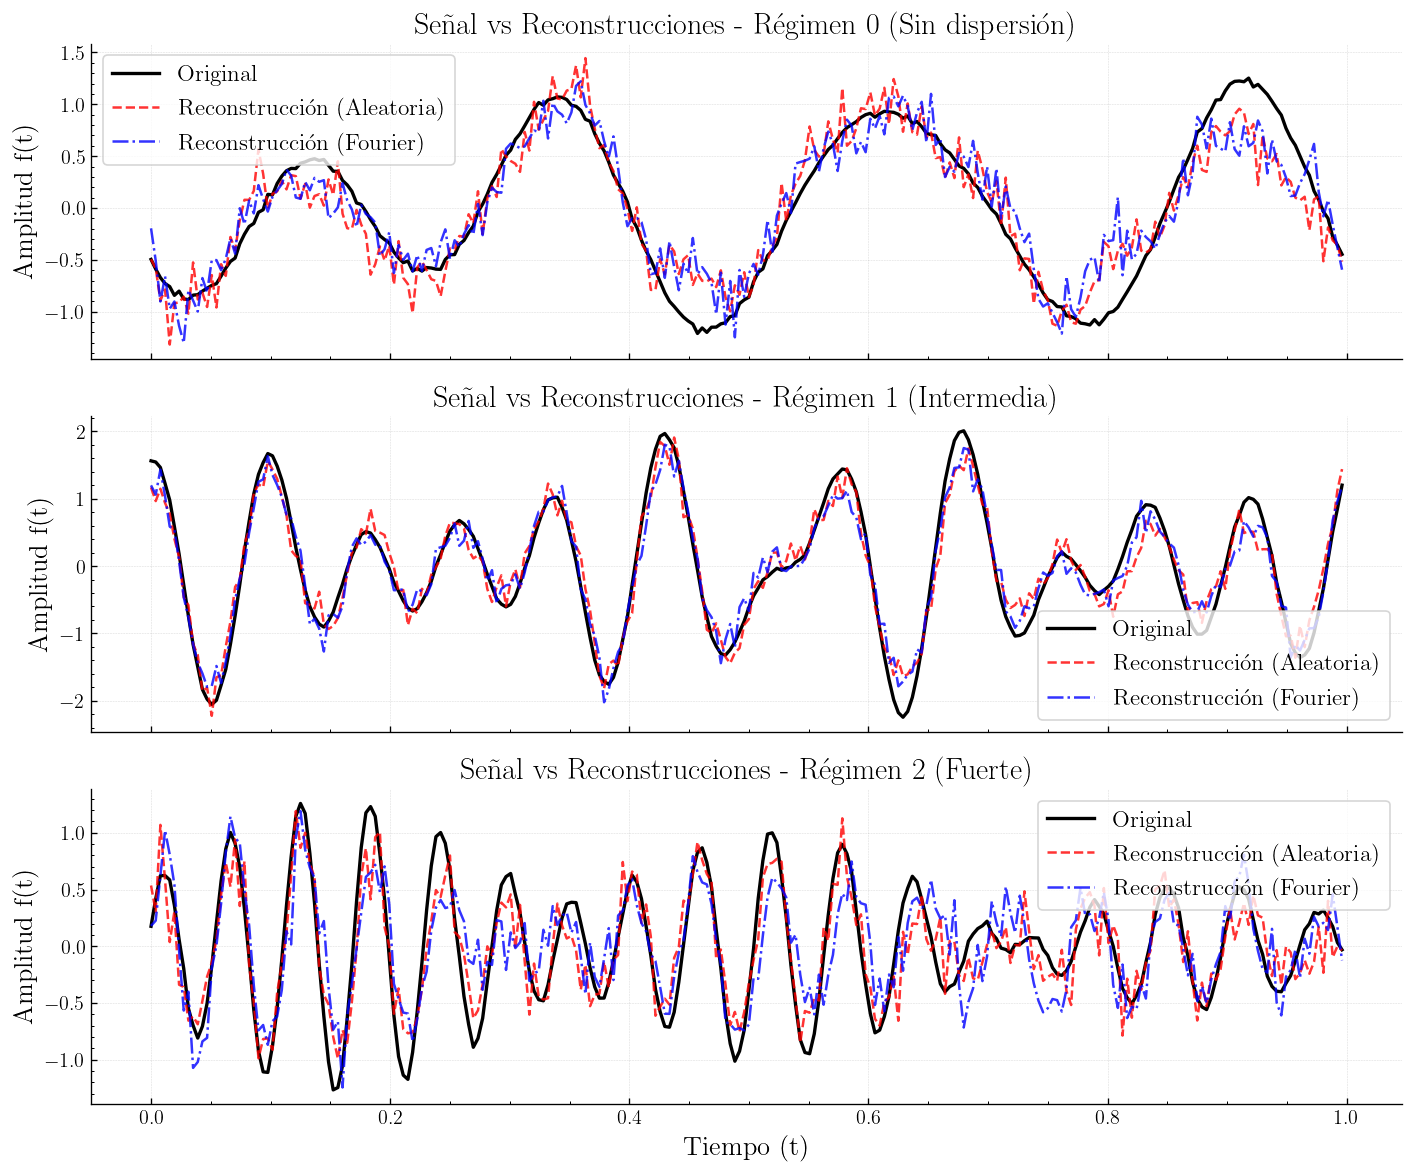

In [5]:
# Definir la función de error relativo solicitada
def calcular_error_relativo(x_real, x_pred):
    """Calcula |x_hat - x| / |x| para un conjunto de señales."""
    # Se utiliza la norma L2 (por defecto en jnp.linalg.norm)
    return jnp.linalg.norm(x_pred - x_real) / jnp.linalg.norm(x_real)

# Obtener las predicciones finales con ambas redes entrenadas
# params_random y params_fourier provienen del bucle de entrenamiento de 3000 iteraciones
X_hat_random = predecir(params_random, X)
X_hat_fourier = predecir(params_fourier, X)

# 3. Reportar el error de reconstrucción relativo global para cada caso
error_rel_random = calcular_error_relativo(X, X_hat_random)
error_rel_fourier = calcular_error_relativo(X, X_hat_fourier)

print(f"Error de reconstrucción relativo (Inicialización Aleatoria): {error_rel_random:.4f}")
print(f"Error de reconstrucción relativo (Inicialización Fourier): {error_rel_fourier:.4f}")

# 4. Preparar las gráficas: una señal de cada régimen
# Buscamos los índices de la primera señal de cada régimen en el vector 'y'
idx_reg0 = jnp.where(y == 0)[0][0]
idx_reg1 = jnp.where(y == 1)[0][0]
idx_reg2 = jnp.where(y == 2)[0][0]

indices = [idx_reg0, idx_reg1, idx_reg2]
titulos = ['Régimen 0 (Sin dispersión)', 'Régimen 1 (Intermedia)', 'Régimen 2 (Fuerte)']

fig, axs = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

for i, (idx, titulo) in enumerate(zip(indices, titulos)):
    # Señal original
    axs[i].plot(t, X[idx], label='Original', color='black', linewidth=2)

    # Reconstrucción red aleatoria
    axs[i].plot(t, X_hat_random[idx], label='Reconstrucción (Aleatoria)',
                color='red', linestyle='--', alpha=0.8)

    # Reconstrucción red Fourier
    axs[i].plot(t, X_hat_fourier[idx], label='Reconstrucción (Fourier)',
                color='blue', linestyle='-.', alpha=0.8)

    axs[i].set_title(f'Señal vs Reconstrucciones - {titulo}')
    axs[i].set_ylabel('Amplitud f(t)')
    axs[i].legend()
    axs[i].grid(True, alpha=0.3)

axs[-1].set_xlabel('Tiempo (t)')
plt.tight_layout()
plt.show()

**¿Debería ser un dato con el que se entreno la red o algún dato de validación?**: Debe ser un dato con el que se entrenó la red, pues no estamos midiendo si la red puede predecir señales nuevas, sino comparando qué tan bien aprende cada inicialización a reconstruir la misma información.

**¿Cuál es la diferencia del error de resconstrucción de cada red-parametrización?:** La diferencia está en que entre más pequeño sea nuestro número de iteraciones mejor aproxima la reconstrución aleatoria, es decir su error relativo es menor, y en cuanto más crece el número de iteraciones, la de Fourier es más preciso. Esto debido a que por la naturaleza del problema, Fourier se aproximará muy bien en cuanto tenga suficiente información, sin embargo, con pocas iteraciones, las ondas sinusoidales pueden no aproximar muy bien.

# 3. Comparación de inicializaciones

Si realizamos nuestra gráfica de comparación unicamente hasta las 3000 iteraciones nos daremos cuenta que no alcanzaremos el valor esperado de 0.1 de error relativo.

Sin embargo, abajo extenderemos las iteraciones y nos daremos cuenta que en valores más altos, además de encontrar el número de iteraciones para el resultado deseado, también notaremos el fenómeno de que, trás un alto número de iteraciones, la reconstrucción de Fourier se aproxima mejor que la aleatoria (en este caso no con el error relativo si no con el cuadrático medio en la gráfica).

Iteraciones para error relativo < 0.1 (Aleatoria): No alcanzó
Iteraciones para error relativo < 0.1 (Fourier): No alcanzó


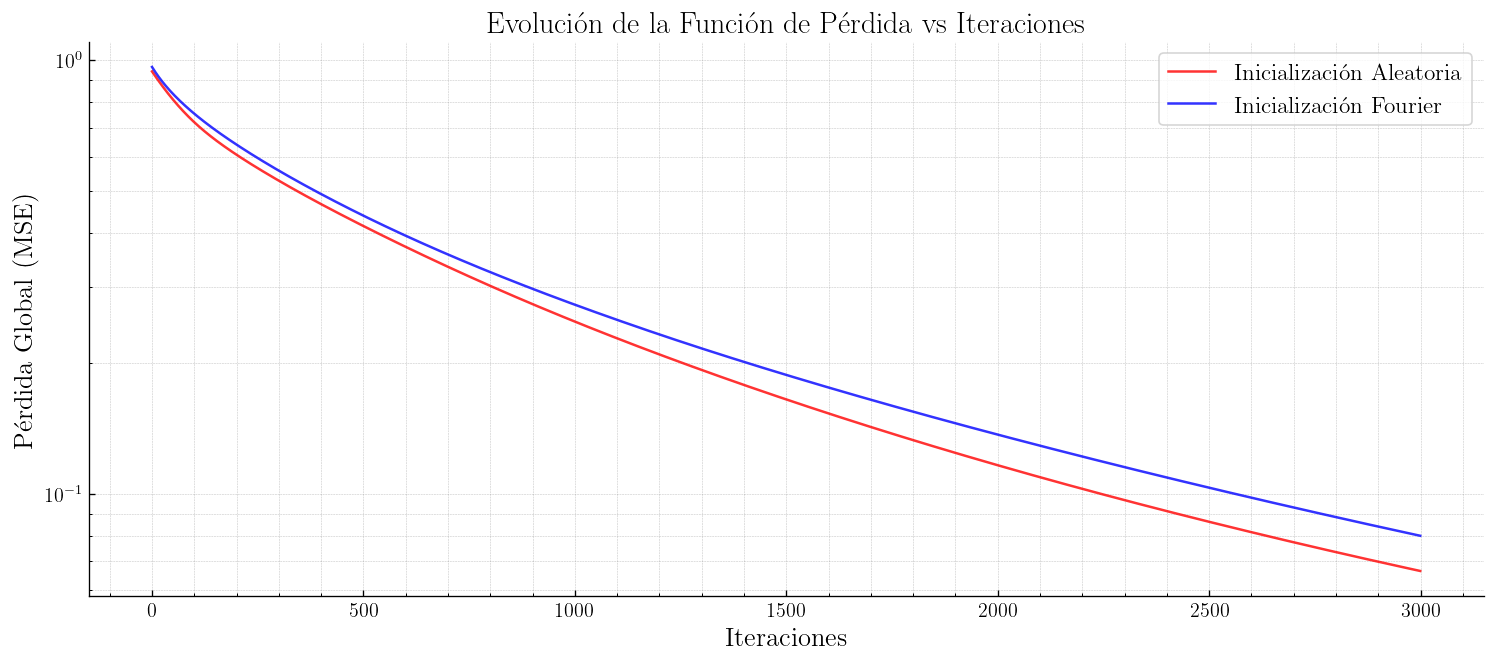

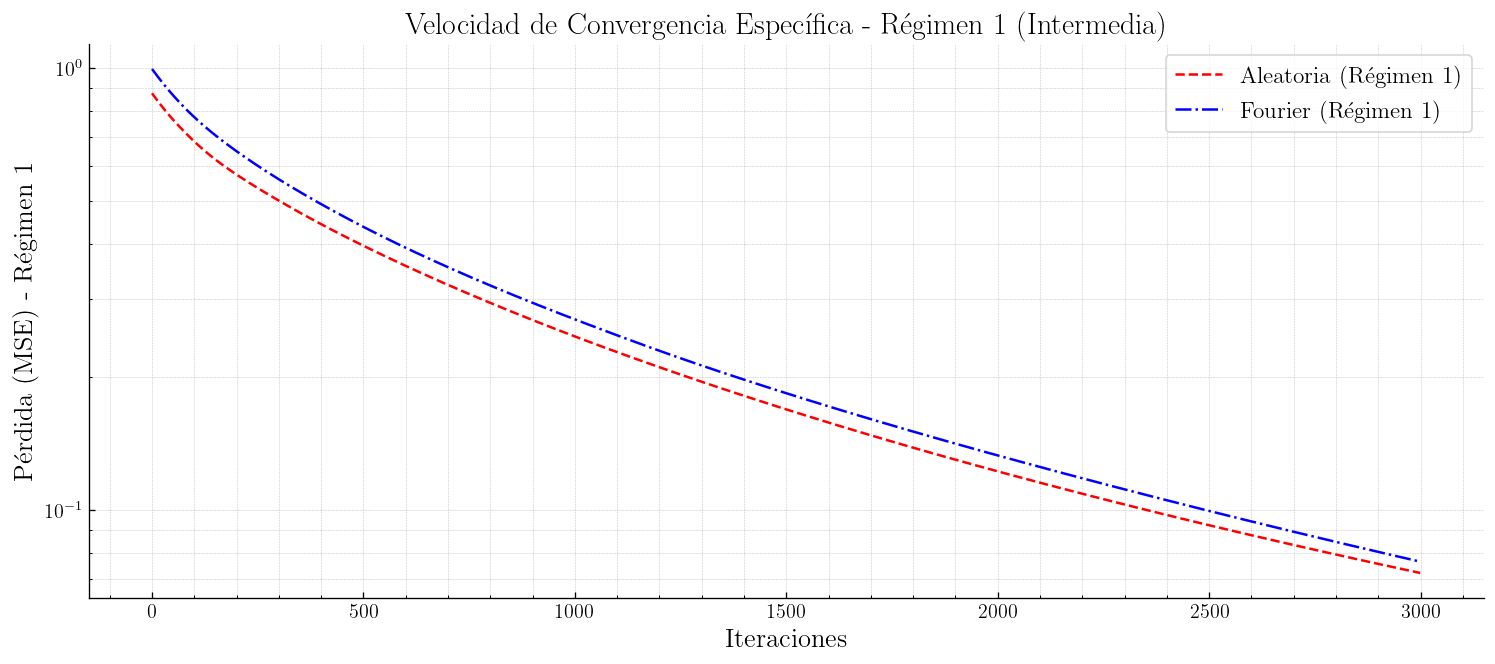

In [6]:
#Comparación de Inicializaciones

# Medición: Cuántas iteraciones necesita cada inicialización para error relativo < 0.1
# Rastrear la pérdida específicamente para el régimen 1 (foco del enunciado)

# Filtramos las señales del régimen 1 (foco del enunciado)
X_reg1_foco = X[y == 1]

# Reiniciamos los parámetros para rastrear exactamente el momento del cruce
# Es importante recrear los parámetros con el mismo estado inicial si se desea medir desde cero
key_w1, key_w2_f, key_w2_r = random.split(random.PRNGKey(42), 3)
W1_random_restart = random.normal(key_w1, (50, 256)) * 0.1
W2_random_restart = random.normal(key_w2_r, (256, 50)) * 0.1
params_r = [W1_random_restart, W2_random_restart]

W1_fourier_restart = construir_capa_fourier(t, K=25)
# Reinitialize W2_fourier for restart as well
key_w2_f_restart = random.PRNGKey(43) # Use a different key for clarity if needed, or same as before if parameters are truly reset
W2_fourier_restart = random.normal(key_w2_f, (256, 50)) * 0.1
params_f = [W1_fourier_restart, W2_fourier_restart]

iter_r_01 = -1
iter_f_01 = -1

loss_reg0_r = []
loss_reg0_f = []

for i in range(iteraciones):
    # --- Red Aleatoria ---
    params_r, _ = update(params_r, X)
    # Calculamos la pérdida solo para el régimen 0
    loss_reg0_r.append(loss_fn(params_r, X_reg1_foco))

    # Revisamos el error relativo global si aún no ha bajado de 0.1
    if iter_r_01 == -1:
        err_r = calcular_error_relativo(X, predecir(params_r, X))
        if err_r < 0.1:
            iter_r_01 = i + 1

    # --- Red Fourier ---
    params_f, _ = update(params_f, X)
    # Calculamos la pérdida solo para el régimen 0
    loss_reg0_f.append(loss_fn(params_f, X_reg1_foco))

    # Revisamos el error relativo global si aún no ha bajado de 0.1
    if iter_f_01 == -1:
        err_f = calcular_error_relativo(X, predecir(params_f, X))
        if err_f < 0.1:
            iter_f_01 = i + 1

# Reporte de iteraciones
print(f"Iteraciones para error relativo < 0.1 (Aleatoria): {'No alcanzó' if iter_r_01 == -1 else iter_r_01}")
print(f"Iteraciones para error relativo < 0.1 (Fourier): {'No alcanzó' if iter_f_01 == -1 else iter_f_01}")

# Gráfica de curvas de la pérdida (L) global vs iteraciones
# (Usando las listas de pérdida global de Parte 2)
plt.figure(figsize=(15, 6)) # Aumentamos el tamaño de la figura para mayor legibilidad
plt.plot(loss_hist_random, label='Inicialización Aleatoria', color='red', alpha=0.8)
plt.plot(loss_hist_fourier, label='Inicialización Fourier', color='blue', alpha=0.8)
plt.yscale('log')
plt.xlabel('Iteraciones')
plt.ylabel('Pérdida Global (MSE)')
plt.title('Evolución de la Función de Pérdida vs Iteraciones')
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

# Gráfica de convergencia para el Régimen 1 (foco)
plt.figure(figsize=(15, 6)) # Aumentamos el tamaño de la figura para mayor legibilidad
plt.plot(loss_reg0_r, label='Aleatoria (Régimen 1)', color='red', linestyle='--')
plt.plot(loss_reg0_f, label='Fourier (Régimen 1)', color='blue', linestyle='-.')
plt.yscale('log')
plt.xlabel('Iteraciones')
plt.ylabel('Pérdida (MSE) - Régimen 1')
plt.title('Velocidad de Convergencia Específica - Régimen 1 (Intermedia)')
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

Iteraciones necesarias para error relativo < 0.1 (Aleatoria): 12013
Iteraciones necesarias para error relativo < 0.1 (Fourier): 10913


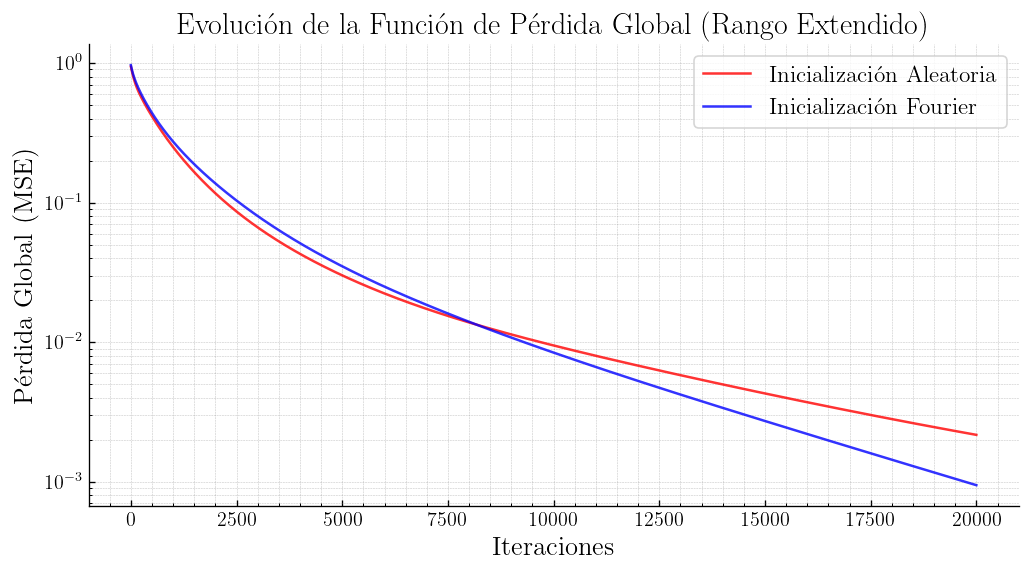

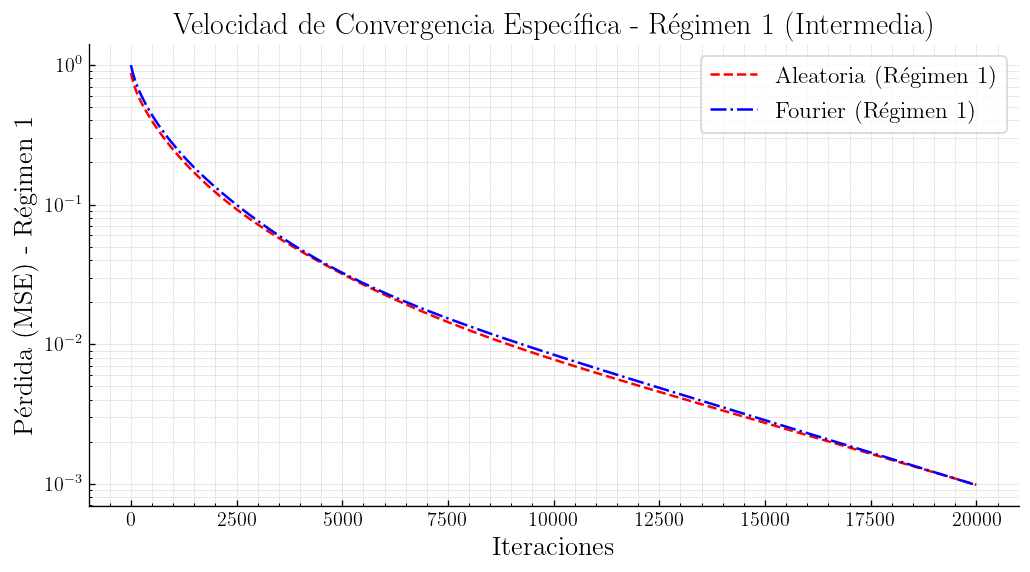

In [7]:
# --- CONTEXTO DE PARAMETRIZACIÓN EXTENDIDA ---
# Incrementamos drásticamente las iteraciones para forzar a las redes a converger por debajo de 0.1
iteraciones_extendidas = 20000
lr_sugerido = 0.05

# Filtrar las señales exclusivas del régimen 1 para el análisis físico (foco del enunciado)
X_reg1_foco = X[y == 1]

# Reiniciamos los parámetros originales para asegurarnos de que el conteo de iteraciones sea exacto desde cero
params_r = [W1_random, W2_random]
params_f = [W1_fourier, W2_fourier]

# Listas para almacenar el historial completo de pérdidas globales
loss_hist_random_ext = []
loss_hist_fourier_ext = []

# Listas para almacenar la pérdida específica del Régimen 1 (foco)
loss_reg0_r = []
loss_reg0_f = []

# Variables para capturar la iteración exacta del cruce del umbral (Error Relativo < 0.1)
iter_r_01 = -1
iter_f_01 = -1

# --- BUCLE DE ENTRENAMIENTO UNIFICADO ---
for i in range(iteraciones_extendidas):
    # 1. Optimización y registro de la Red Aleatoria
    params_r, loss_r = update(params_r, X)
    loss_hist_random_ext.append(loss_r)
    loss_reg0_r.append(loss_fn(params_r, X_reg1_foco))

    # Evaluar si la red aleatoria cruza el umbral de error relativo de 0.1
    if iter_r_01 == -1:
        err_r_actual = calcular_error_relativo(X, predecir(params_r, X))
        if err_r_actual < 0.1:
            iter_r_01 = i + 1  # Guardamos la iteración real (base 1)

    # 2. Optimización y registro de la Red Fourier
    params_f, loss_f = update(params_f, X)
    loss_hist_fourier_ext.append(loss_f)
    loss_reg0_f.append(loss_fn(params_f, X_reg1_foco))

    # Evaluar si la red de Fourier cruza el umbral de error relativo de 0.1
    if iter_f_01 == -1:
        err_f_actual = calcular_error_relativo(X, predecir(params_f, X))
        if err_f_actual < 0.1:
            iter_f_01 = i + 1  # Guardamos la iteración real (base 1)

# --- REPORTE DE MEDICIONES REQUERIDAS ---
print(f"Iteraciones necesarias para error relativo < 0.1 (Aleatoria): {'No alcanzó el objetivo' if iter_r_01 == -1 else iter_r_01}")
print(f"Iteraciones necesarias para error relativo < 0.1 (Fourier): {'No alcanzó el objetivo' if iter_f_01 == -1 else iter_f_01}")

# --- VISUALIZACIÓN CIENTÍFICA ---

# Gráfica 1: Curvas de pérdida global superpuestas
plt.figure(figsize=(10, 5))
plt.plot(loss_hist_random_ext, label='Inicialización Aleatoria', color='red', alpha=0.8)
plt.plot(loss_hist_fourier_ext, label='Inicialización Fourier', color='blue', alpha=0.8)
plt.yscale('log')
plt.xlabel('Iteraciones')
plt.ylabel('Pérdida Global (MSE)')
plt.title('Evolución de la Función de Pérdida Global (Rango Extendido)')
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

# Gráfica 2: Velocidad de convergencia específica para el Régimen 1 (foco)
plt.figure(figsize=(10, 5))
plt.plot(loss_reg0_r, label='Aleatoria (Régimen 1)', color='red', linestyle='--')
plt.plot(loss_reg0_f, label='Fourier (Régimen 1)', color='blue', linestyle='-.')
plt.yscale('log')
plt.xlabel('Iteraciones')
plt.ylabel('Pérdida (MSE) - Régimen 1')
plt.title('Velocidad de Convergencia Específica - Régimen 1 (Intermedia)')
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

**¿La pérdida es el error relativo?:** No, este caso la pérdida global es el error cuadrático medio, ya que la red usa mínimos cuadrados para optimizar pesos.

**Análisis de las gráfica del Régimen 0:** Podemos notar que para el regimen 0, la inicialización aleatoria disminuye su error cuadrático de manera más acelearada durante las primeras 14.000 iteraciones, esto debido a que esta reconstrucción tiene una estructura menos rígida que la de Fourier, sin embargo, pasadas las 14.000 iteraciones, debido a la naturaleza del problema, la reconstrucción de Fourier empieza a tener un MSE más bajo en relación al número de iteraciones.

# 4. Compresión

Bastan 38 coeficientes para conservar el 90% de la energía.


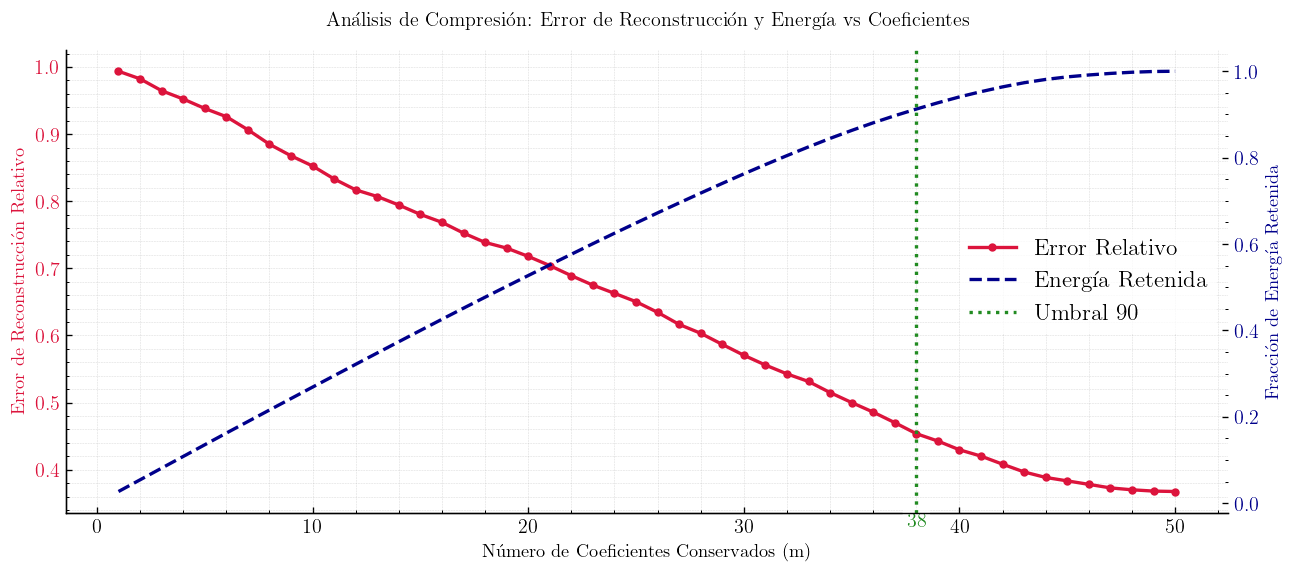

In [8]:
# --- Parte 4: Análisis de Compresión ---

# Extraer los pesos finales entrenados de la red de Fourier
W1_entrenado, W2_entrenado = params_fourier

# Calcular las activaciones de la capa oculta (los coeficientes) para todo el dataset
# Forma de Z: (30 señales, 50 coeficientes)
Z = jnp.tanh(jnp.dot(X, W1_entrenado.T))

# Ordenar los coeficientes por su magnitud (valor absoluto) para cada señal
# Queremos saber cuáles son los coeficientes más "importantes" de mayor a menor
indices_ordenados = jnp.argsort(jnp.abs(Z), axis=1)[:, ::-1]

errores_reconstruccion_m = []
energia_retenida_m = []

# Evaluar el impacto de conservar desde 1 hasta 50 coeficientes
for m in range(1, 51):
    # Creamos una matriz de coeficientes truncados llena de ceros
    Z_truncado = np.zeros_like(Z)

    # Para cada una de las 30 señales, preservamos solo los 'm' coeficientes más grandes
    for i in range(X.shape[0]):
        indices_top = indices_ordenados[i, :m]
        Z_truncado[i, indices_top] = Z[i, indices_top]

    Z_truncado = jnp.array(Z_truncado)

    # Reconstruimos el dataset usando solo esos 'm' coeficientes
    X_hat_m = jnp.dot(Z_truncado, W2_entrenado.T)

    # Calcular el error relativo promedio de todo el dataset para este 'm'
    error_rel_m = jnp.mean(jnp.linalg.norm(X_hat_m - X, axis=1) / jnp.linalg.norm(X, axis=1))
    errores_reconstruccion_m.append(error_rel_m)

    # Calcular el porcentaje de energía promedio retenida en la capa oculta
    energia_total = jnp.sum(Z**2, axis=1)
    energia_m = jnp.sum(Z_truncado**2, axis=1)
    pct_energia = jnp.mean(energia_m / energia_total)
    energia_retenida_m.append(pct_energia)

# Encontrar el 'm' mínimo que supera el umbral del 90% (0.90) de la energía
num_coeficientes_90 = -1
for m_idx, pct in enumerate(energia_retenida_m):
    if pct >= 0.90:
        num_coeficientes_90 = m_idx + 1  # +1 porque los índices van de 0 a 49
        break

print(f"Bastan {num_coeficientes_90} coeficientes para conservar el 90% de la energía.")

# --- VISUALIZACIÓN CIENTÍFICA ---
fig, ax1 = plt.subplots(figsize=(11, 5))

# Curva principal: Error de reconstrucción vs Coeficientes
color_err = 'crimson'
ax1.set_xlabel('Número de Coeficientes Conservados (m)', fontsize=11)
ax1.set_ylabel('Error de Reconstrucción Relativo', color=color_err, fontsize=11)
line1 = ax1.plot(range(1, 51), errores_reconstruccion_m, color=color_err,
                 linewidth=2, label='Error Relativo', marker='o', markersize=4)
ax1.tick_params(axis='y', labelcolor=color_err)
ax1.grid(True, which='both', linestyle='--', alpha=0.3)

# Eje secundario para mostrar la energía acumulada
ax2 = ax1.twinx()
color_eng = 'darkblue'
ax2.set_ylabel('Fracción de Energía Retenida', color=color_eng, fontsize=11)
line2 = ax2.plot(range(1, 51), energia_retenida_m, color=color_eng,
                 linewidth=2, linestyle='--', label='Energía Retenida')
ax2.tick_params(axis='y', labelcolor=color_eng)

# Línea vertical indicando el umbral del 90% exigido
if num_coeficientes_90 != -1:
    plt.axvline(x=num_coeficientes_90, color='forestgreen', linestyle=':', linewidth=2,
                label=f'Umbral 90% Energía (m = {num_coeficientes_90})')
    # Add the text '38' at the bottom of the vertical line
    ax1.text(num_coeficientes_90, ax1.get_ylim()[0], str(num_coeficientes_90),
             verticalalignment='top', horizontalalignment='center',
             color='forestgreen', fontsize=12, weight='bold',
             bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.2', alpha=0.7))

# Juntar leyendas de ambos ejes
lineas = line1 + line2 + [plt.gca().get_lines()[-1]]
etiquetas = [l.get_label() for l in lineas]
ax1.legend(lineas, etiquetas, loc='center right', frameon=True, facecolor='white', edgecolor='none')

plt.title('Análisis de Compresión: Error de Reconstrucción y Energía vs Coeficientes', fontsize=12, pad=15)
plt.tight_layout()
plt.show()

Reportar la energía media del dataset (calculada al inicio) es fundamental porque establece la línea base física de nuestras señales. En el estudio de ondas, la energía está directamente relacionada con la amplitud al cuadrado de sus componentes armónicos. Conocer este valor nos permite garantizar que el criterio de compresión basado en el 90% de la energía sea matemáticamente preciso en relación con la magnitud real de la información que estamos intentando salvar.